# WP-08: Audio Enhancement Pipeline — PoC

**Goal:** Build and validate a 7-stage audio enhancement pipeline for old tango recordings.  
**Philosophy:** Minimal intervention — subtle corrections to make tracks within a tanda sound consistent, not to transform the audio character.

## Section A: Single Track Exploration

In [163]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr
import pedalboard
import pyloudnorm as pyln
import matplotlib.pyplot as plt
import IPython.display as ipd
from pathlib import Path

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(exist_ok=True)

print('All imports OK')

All imports OK


### Step 1: Load a track and listen to the original

In [164]:
# Pick an older recording likely to have hiss/noise
track_path = RAW_DIR / '01 Al Compas De Un Tango.mp3'
print(f'Loading: {track_path.name}')

# Load at native sample rate, keep as mono for simplicity
audio_orig, sr = librosa.load(str(track_path), sr=None, mono=True)
print(f'Sample rate: {sr} Hz, Duration: {len(audio_orig)/sr:.1f}s, Shape: {audio_orig.shape}')

# Listen to original
print('\n--- Original ---')
# ipd.display(ipd.Audio(audio_orig, rate=sr))  # commented out — embeds large audio in notebook

Loading: 01 Al Compas De Un Tango.mp3
Sample rate: 44100 Hz, Duration: 158.7s, Shape: (6998400,)

--- Original ---


### Step 2: Measure SNR before enhancement

In [165]:
def measure_snr(audio, sr):
    """Estimate SNR by comparing energy in signal band (200-4000Hz) vs noise band (8000-16000Hz)."""
    n_fft = 2048
    S = np.abs(librosa.stft(audio, n_fft=n_fft))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    
    # Signal band: 200-4000 Hz (where tango music lives)
    sig_mask = (freqs >= 200) & (freqs <= 4000)
    sig_energy = np.mean(S[sig_mask, :] ** 2)
    
    # Noise band: 8000-16000 Hz (where hiss lives)
    noise_mask = (freqs >= 8000) & (freqs <= min(16000, sr // 2))
    if not noise_mask.any():
        return float('inf')
    noise_energy = np.mean(S[noise_mask, :] ** 2)
    
    if noise_energy == 0:
        return float('inf')
    return 10 * np.log10(sig_energy / noise_energy)


def find_music_cutoff(audio, sr, threshold_db=-40, min_cutoff=5000.0):
    """Find the frequency where musical energy drops off.
    
    Computes the average energy at each frequency across the whole track.
    Walks from high frequencies downward until energy rises above threshold_db
    (relative to the loudest frequency). That's where music ends and only
    noise/artifacts remain. Returns the cutoff frequency in Hz.
    
    min_cutoff: safety floor so we never cut into the music (default 5kHz).
    """
    n_fft = 2048
    S = np.abs(librosa.stft(audio, n_fft=n_fft))
    avg_spectrum = np.mean(S, axis=1)
    avg_db = 20 * np.log10(avg_spectrum + 1e-10)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    
    peak_db = avg_db.max()
    
    # Walk from high frequency to low, find first bin above threshold
    for i in range(len(freqs) - 1, -1, -1):
        if avg_db[i] > (peak_db + threshold_db):
            cutoff = min(freqs[i] + 500, sr // 2)  # add 500Hz margin
            return max(cutoff, min_cutoff)
    
    return min_cutoff  # fallback


snr_before = measure_snr(audio_orig, sr)
print(f'SNR before: {snr_before:.1f} dB')

music_cutoff = find_music_cutoff(audio_orig, sr)
print(f'Music cutoff: {music_cutoff:.0f} Hz (dynamic — will use as lowpass filter)')

SNR before: 73.4 dB
Music cutoff: 5883 Hz (dynamic — will use as lowpass filter)


### Step 3: Noise reduction (light, minimal intervention)

In [166]:
import time
t_pipeline_start = time.time()

# Light noise reduction — prop_decrease=0.5 means reduce noise by 50%, not eliminate it
# This preserves the character of the recording while reducing obvious hiss
audio_nr = nr.reduce_noise(
    y=audio_orig,
    sr=sr,
    prop_decrease=0.5,   # gentle — 0.0 = no reduction, 1.0 = full reduction
    stationary=True,     # assume stationary noise (tape hiss is constant)
)
print(f'Noise reduction done. prop_decrease=0.5 (gentle)')
print(f'SNR after noise reduction: {measure_snr(audio_nr, sr):.1f} dB')

Noise reduction done. prop_decrease=0.5 (gentle)
SNR after noise reduction: 69.8 dB


### Step 5: EQ — subtle "tango warmth" preset

In [167]:
# Subtle EQ to bring out bandoneón and vocals without changing the character
# - High-pass at 80Hz: remove rumble
# - Low shelf boost at 800Hz, +2dB: warm up bandoneón body
# - Peak boost at 2kHz, +1.5dB: bring out vocal presence
board_eq = pedalboard.Pedalboard([
    pedalboard.HighpassFilter(cutoff_frequency_hz=80.0),
    pedalboard.LowShelfFilter(cutoff_frequency_hz=800.0, gain_db=2.0),
    pedalboard.PeakFilter(cutoff_frequency_hz=2000.0, gain_db=1.5, q=0.7),
])

audio_eq = board_eq(audio_nr.astype(np.float32).reshape(1, -1), sr).flatten()
print(f'EQ done. Tango warmth preset (subtle: +2dB low-shelf, +1.5dB vocal peak)')

EQ done. Tango warmth preset (subtle: +2dB low-shelf, +1.5dB vocal peak)


### Step 6: LUFS normalization (consistent perceived loudness)

In [168]:
# Normalize to -14.0 LUFS — standard streaming loudness
TARGET_LUFS = -14.0

meter = pyln.Meter(sr)
current_lufs = meter.integrated_loudness(audio_eq)
print(f'Current LUFS: {current_lufs:.1f}')

audio_lufs = pyln.normalize.loudness(audio_eq, current_lufs, TARGET_LUFS)
print(f'Normalized LUFS: {meter.integrated_loudness(audio_lufs):.1f} (target: {TARGET_LUFS})')

Current LUFS: -22.9
Normalized LUFS: -14.0 (target: -14.0)


c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


### Step 7: Limiter + Dynamic hiss filter

In [169]:
# Limiter AFTER LUFS normalization — catches peaks created by the volume boost
# Then dynamic hiss filter (3x stacked) to clean up amplified artifacts
print(f'Dynamic cutoff: {music_cutoff:.0f} Hz (from find_music_cutoff)')

board_final = pedalboard.Pedalboard([
    pedalboard.Limiter(threshold_db=-1.0),
    pedalboard.LowpassFilter(cutoff_frequency_hz=music_cutoff),
    pedalboard.LowpassFilter(cutoff_frequency_hz=music_cutoff),
    pedalboard.LowpassFilter(cutoff_frequency_hz=music_cutoff),
])
audio_limited = board_final(audio_lufs.astype(np.float32).reshape(1, -1), sr).flatten()

audio_final = np.clip(audio_limited, -1.0, 1.0)

final_lufs = meter.integrated_loudness(audio_final)
peak_db = 20 * np.log10(np.max(np.abs(audio_final)) + 1e-10)
print(f'Peak: {peak_db:.1f} dBFS (should be <= -1.0)')
print(f'Final LUFS: {final_lufs:.1f}')
print(f'Pipeline: noise reduction → EQ → LUFS norm → limiter → dynamic hiss filter ({music_cutoff:.0f} Hz)')

Dynamic cutoff: 5883 Hz (from find_music_cutoff)
Peak: -0.1 dBFS (should be <= -1.0)
Final LUFS: -13.2
Pipeline: noise reduction → EQ → LUFS norm → limiter → dynamic hiss filter (5883 Hz)


### Results: Before vs After

In [170]:
t_pipeline_end = time.time()
pipeline_elapsed = t_pipeline_end - t_pipeline_start
track_duration = len(audio_orig) / sr

snr_after = measure_snr(audio_final, sr)
print(f'SNR before:  {snr_before:.1f} dB')
print(f'SNR after:   {snr_after:.1f} dB')
print(f'SNR delta:   +{snr_after - snr_before:.1f} dB')
print(f'LUFS:        {final_lufs:.1f}')
print(f'Peak:        {20 * np.log10(np.max(np.abs(audio_final)) + 1e-10):.1f} dBFS')
print(f'\nLatency:     {pipeline_elapsed:.1f}s for {track_duration:.1f}s track ({pipeline_elapsed/track_duration:.3f}x realtime)')

SNR before:  73.4 dB
SNR after:   76.0 dB
SNR delta:   +2.6 dB
LUFS:        -13.2
Peak:        -0.1 dBFS

Latency:     4.0s for 158.7s track (0.025x realtime)


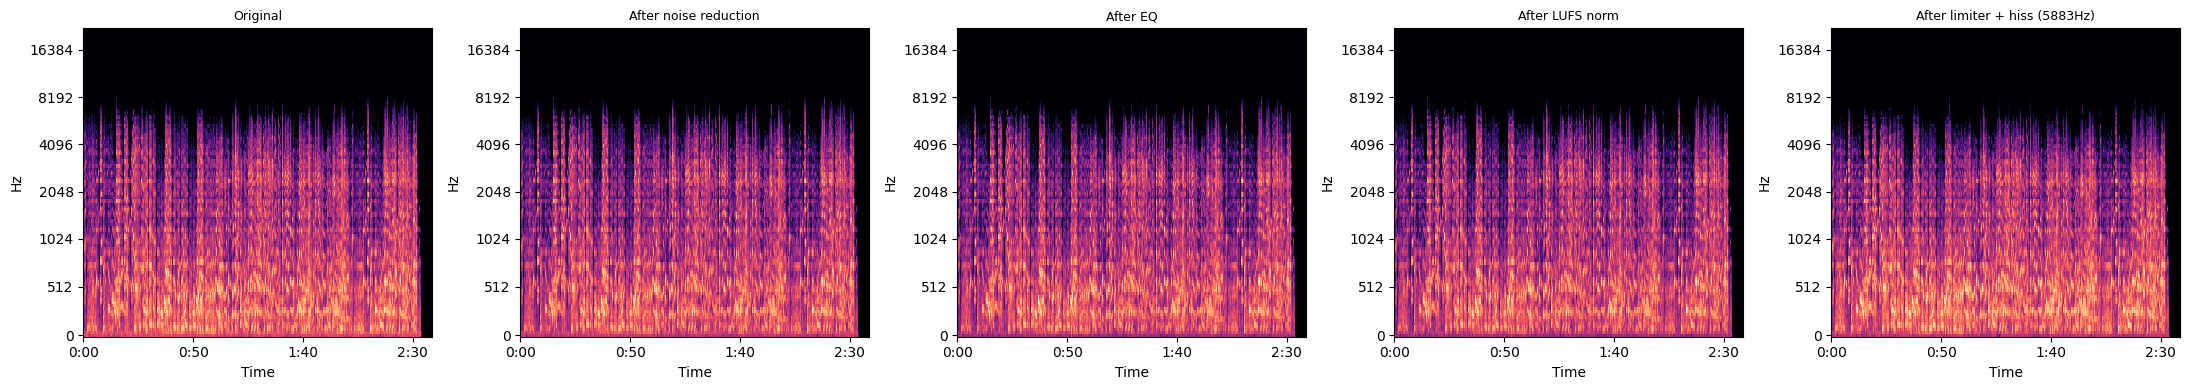

In [171]:
# Per-step spectrograms
# Pipeline order: noise reduction → EQ → LUFS norm → limiter + dynamic hiss filter
stages = {
    'Original': audio_orig,
    'After noise reduction': audio_nr,
    'After EQ': audio_eq,
    'After LUFS norm': audio_lufs,
    f'After limiter + hiss ({music_cutoff:.0f}Hz)': audio_final,
}

# Compute all mel spectrograms
specs = {}
for label, audio in stages.items():
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    specs[label] = S

# Shared reference across ALL stages for honest comparison
shared_ref = max(S.max() for S in specs.values())

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (label, S) in zip(axes.flat, specs.items()):
    librosa.display.specshow(librosa.power_to_db(S, ref=shared_ref),
                             sr=sr, ax=ax, x_axis='time', y_axis='mel')
    ax.set_title(label, fontsize=9)

plt.tight_layout()
plt.show()

### Reading the per-step spectrograms

Pipeline order: noise reduction → EQ → LUFS norm → limiter → dynamic hiss filter

| Step | What it does | Expected change in spectrogram |
|---|---|---|
| **Original** | Raw recording, no processing | Baseline — bright haze above ~8kHz is tape hiss, warm colors in 200–4000Hz are the music |
| **After noise reduction** | Removes constant background hiss. `noise_prop` controls strength (0.2 = gentle, 0.8 = strong) | High-frequency haze should dim. Music stays the same. May introduce tiny artifacts |
| **After EQ** | Adjusts tone balance: removes rumble below 80Hz, adds warmth at 800Hz, adds vocal clarity at 2kHz | Bottom edge (below 80Hz) gets darker. Subtle brightness increase around 800Hz and 2kHz |
| **After LUFS norm** | Makes perceived loudness consistent (-14 LUFS). Scales the entire signal uniformly | Uniform brightness shift. Spikes may appear because volume boost amplifies tiny artifacts |
| **After limiter + hiss filter** | Limiter catches peaks from LUFS boost (prevents clipping). Then dynamic lowpass removes everything above the music's natural frequency ceiling | Peaks capped, high-frequency artifacts cleaned up. Clean final result |

In [172]:
# Listen to both — the difference should be subtle but noticeable
print('--- Original ---')
# ipd.display(ipd.Audio(audio_orig, rate=sr))  # commented out — embeds large audio in notebook

print('\n--- Enhanced ---')
# ipd.display(ipd.Audio(audio_final, rate=sr))  # commented out — embeds large audio in notebook

--- Original ---

--- Enhanced ---


In [173]:
# Save the enhanced version
output_path = PROCESSED_DIR / (track_path.stem + '_enhanced.wav')
sf.write(str(output_path), audio_final, sr)
print(f'Saved: {output_path}')

Saved: ..\data\processed\01 Al Compas De Un Tango_enhanced.wav


---
## Section B: Per-Tanda Adaptive Enhancement

The fixed parameters in Section A work for a single track, but applying the same params to every track is just batch processing -- no reason to do it live. Instead, we **analyze the tanda first**, then adapt parameters per-track so the group sounds more consistent while each tanda keeps its own character.

**Adaptive parameters** (vary per-track based on tanda analysis):
- `noise_prop` -- scaled by track SNR vs tanda median SNR (noisier tracks get more reduction)
- `eq_low_gain` / `eq_vocal_gain` -- scaled by spectral centroid vs tanda median (pushes all tracks toward the same tonal balance)
- `hiss_cutoff` -- dynamic per-track, set where musical energy drops off (via `find_music_cutoff`)

**Fixed parameters** (physics/playback standards, never change):
- `highpass=80Hz`, `target_lufs=-14`, `limiter=-1dBFS`

In [174]:
def measure_spectral_centroid(audio, sr):
    """Compute the mean spectral centroid of an audio signal.
    
    Spectral centroid = the "center of mass" of the frequency spectrum (in Hz).
    Higher value = brighter/thinner sound (energy in high frequencies).
    Lower value = warmer/darker sound (energy in low frequencies).
    A real tango DJ adjusts EQ knobs to match brightness across tracks —
    this metric lets us do the same thing automatically.
    """
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    return float(np.mean(centroid))


def analyze_tanda_tracks(track_paths):
    """MEASURE: Load each track and compute its audio profile.
    
    Returns a list of dicts with per-track metrics:
      - snr: signal-to-noise ratio (higher = cleaner)
      - lufs: perceived loudness
      - spectral_centroid: brightness in Hz (higher = brighter)
    These measurements feed into compute_per_track_params() to decide
    how much enhancement each track needs relative to the group.
    """
    import pyloudnorm as pyln
    
    profiles = []
    for tp in track_paths:
        audio, sr = librosa.load(str(tp), sr=None, mono=True)
        meter = pyln.Meter(sr)
        profiles.append({
            'path': tp,
            'name': tp.stem,
            'snr': measure_snr(audio, sr),
            'lufs': meter.integrated_loudness(audio),
            'spectral_centroid': measure_spectral_centroid(audio, sr),
            'sr': sr,
        })
    return profiles


def compute_per_track_params(profiles):
    """DECIDE: Derive per-track enhancement parameters from tanda analysis.
    
    Compares each track to the tanda median and scales adaptive params:
      - noise_prop: noisier tracks (low SNR) get more noise reduction
      - eq_low_gain: brighter tracks get more warmth (low-shelf boost)
      - eq_vocal_gain: darker tracks get more vocal presence (2kHz peak)
    
    Fixed params (physics/playback) are the same for all tracks.
    """
    snrs = [p['snr'] for p in profiles]
    centroids = [p['spectral_centroid'] for p in profiles]
    
    median_snr = np.median(snrs)
    median_centroid = np.median(centroids)
    snr_range = max(np.ptp(snrs), 1.0)  # ptp = max - min; avoid division by zero
    centroid_range = max(np.ptp(centroids), 1.0)
    
    params_list = []
    for p in profiles:
        # Noise reduction: scale by how far below median SNR this track is
        # Noisier track (low SNR) → higher prop_decrease → more noise removed
        noise_prop = np.clip(0.2 + 0.5 * (median_snr - p['snr']) / snr_range, 0.2, 0.8)
        
        # EQ: scale by spectral centroid distance from tanda median
        # centroid_offset > 0 means track is brighter than median
        centroid_offset = (p['spectral_centroid'] - median_centroid) / centroid_range
        
        # Brighter track → more low-shelf warmth, less vocal peak
        # Darker track → less low-shelf warmth, more vocal peak
        eq_low_gain = np.clip(2.0 + 1.5 * centroid_offset, 0.0, 3.5)
        eq_vocal_gain = np.clip(1.5 - 1.5 * centroid_offset, 0.0, 3.5)
        
        params_list.append({
            'name': p['name'],
            'noise_prop': round(float(noise_prop), 3),
            'eq_low_gain': round(float(eq_low_gain), 2),
            'eq_vocal_gain': round(float(eq_vocal_gain), 2),
            # Fixed params (same for all tracks)
            'hiss_hz': 10000.0,
            'target_lufs': -14.0,
        })
    
    return params_list, {
        'median_snr': round(median_snr, 1),
        'median_centroid': round(median_centroid, 1),
        'snr_range': round(snr_range, 1),
        'centroid_range': round(centroid_range, 1),
    }


# enhance_track_pipeline() already accepts these as keyword args — no changes needed
print('Analysis and adaptive parameter functions defined.')

Analysis and adaptive parameter functions defined.


In [175]:
def enhance_track_pipeline(input_path, sr_out=None, noise_prop=0.5,
                           eq_low_gain=2.0, eq_vocal_gain=1.5, target_lufs=-14.0):
    """APPLY: Full pipeline with given parameters.
    
    Pipeline order: noise reduction → EQ → LUFS norm → limiter → dynamic hiss filter (3x stacked).
    The hiss filter cutoff is computed per-track by find_music_cutoff().
    Returns (enhanced_audio, sr, metrics_dict).
    """
    # 1. Read
    audio, sr = librosa.load(str(input_path), sr=sr_out, mono=True)
    snr_before = measure_snr(audio, sr)
    centroid_before = measure_spectral_centroid(audio, sr)
    hiss_cutoff = find_music_cutoff(audio, sr)
    
    # 2. Noise reduction (adaptive: noise_prop varies per track)
    audio = nr.reduce_noise(y=audio, sr=sr, prop_decrease=noise_prop, stationary=True)
    
    # 3. EQ (adaptive: gains vary)
    board_eq = pedalboard.Pedalboard([
        pedalboard.HighpassFilter(cutoff_frequency_hz=80.0),
        pedalboard.LowShelfFilter(cutoff_frequency_hz=800.0, gain_db=eq_low_gain),
        pedalboard.PeakFilter(cutoff_frequency_hz=2000.0, gain_db=eq_vocal_gain, q=0.7),
    ])
    audio = board_eq(audio.astype(np.float32).reshape(1, -1), sr).flatten()
    
    # 4. LUFS normalization (fixed: -14 LUFS)
    meter = pyln.Meter(sr)
    current_lufs = meter.integrated_loudness(audio)
    audio = pyln.normalize.loudness(audio, current_lufs, target_lufs)
    
    # 5. Limiter (catches peaks from LUFS boost) + dynamic hiss filter (3x stacked)
    board_final = pedalboard.Pedalboard([
        pedalboard.Limiter(threshold_db=-1.0),
        pedalboard.LowpassFilter(cutoff_frequency_hz=hiss_cutoff),
        pedalboard.LowpassFilter(cutoff_frequency_hz=hiss_cutoff),
        pedalboard.LowpassFilter(cutoff_frequency_hz=hiss_cutoff),
    ])
    audio = board_final(audio.astype(np.float32).reshape(1, -1), sr).flatten()
    audio = np.clip(audio, -1.0, 1.0)
    
    snr_after = measure_snr(audio, sr)
    centroid_after = measure_spectral_centroid(audio, sr)
    final_lufs = meter.integrated_loudness(audio)
    peak_db = 20 * np.log10(np.max(np.abs(audio)) + 1e-10)
    
    metrics = {
        'snr_before': snr_before,
        'snr_after': snr_after,
        'snr_delta': snr_after - snr_before,
        'lufs': final_lufs,
        'peak_db': peak_db,
        'centroid_before': centroid_before,
        'centroid_after': centroid_after,
        'hiss_cutoff': hiss_cutoff,
    }
    return audio, sr, metrics

print('Pipeline function defined.')

Pipeline function defined.


In [176]:
# --- Step 1: MEASURE — Analyze all tanda tracks before enhancing ---
# Picked tracks from different decades to maximize recording quality differences:
#   1937 — Pedro Laurenz (older, likely more hiss)
#   1942 — Ricardo Tanturi (golden age, moderate quality)
#   1957 — Carlos Di Sarli (later, cleaner recording)

tanda_tracks = [
    RAW_DIR / '01 Arrabal.mp3',              # 1937, Pedro Laurenz
    RAW_DIR / '01 Al Compas De Un Tango.mp3', # 1942, Ricardo Tanturi
    RAW_DIR / '01 Cara Sucia.mp3',            # 1957, Carlos Di Sarli
]

# Check which tracks exist
tanda_tracks = [t for t in tanda_tracks if t.exists()]
print(f'Tanda tracks found: {len(tanda_tracks)}/{3}')
for t in tanda_tracks:
    print(f'  {t.name}')

# Analyze: measure SNR, LUFS, spectral centroid for each track
profiles = analyze_tanda_tracks(tanda_tracks)

import pandas as pd
df_profiles = pd.DataFrame([{
    'track': p['name'],
    'SNR (dB)': round(p['snr'], 1),
    'LUFS': round(p['lufs'], 1),
    'spectral_centroid (Hz)': round(p['spectral_centroid'], 1),
} for p in profiles])

print('\n--- Raw Audio Profiles (before enhancement) ---')
print(df_profiles.to_string(index=False))
print(f'\nVariation (std dev):')
print(f'  SNR:               {np.std([p["snr"] for p in profiles]):.1f} dB')
print(f'  LUFS:              {np.std([p["lufs"] for p in profiles]):.1f} LU')
print(f'  Spectral centroid: {np.std([p["spectral_centroid"] for p in profiles]):.1f} Hz')

Tanda tracks found: 3/3
  01 Arrabal.mp3
  01 Al Compas De Un Tango.mp3
  01 Cara Sucia.mp3



--- Raw Audio Profiles (before enhancement) ---
                   track  SNR (dB)  LUFS  spectral_centroid (Hz)
              01 Arrabal 63.200001 -19.4                   943.9
01 Al Compas De Un Tango 73.400002 -20.5                  1108.4
           01 Cara Sucia 36.799999 -18.1                  1361.9

Variation (std dev):
  SNR:               15.4 dB
  LUFS:              1.0 LU
  Spectral centroid: 171.9 Hz


In [177]:
# --- Step 2: DECIDE — Compute adaptive per-track parameters ---

per_track_params, tanda_summary = compute_per_track_params(profiles)

print(f'Tanda medians: SNR={tanda_summary["median_snr"]} dB, '
      f'centroid={tanda_summary["median_centroid"]} Hz\n')

# Show raw measurements alongside adaptive params so we can see WHY each param was chosen
df_decision = pd.DataFrame([{
    'track': p['name'],
    'SNR (dB)': round(profiles[i]['snr'], 1),
    'centroid (Hz)': round(profiles[i]['spectral_centroid'], 1),
    '→ noise_prop': p['noise_prop'],
    '→ eq_low (dB)': p['eq_low_gain'],
    '→ eq_vocal (dB)': p['eq_vocal_gain'],
} for i, p in enumerate(per_track_params)])

print('--- Measurements → Adaptive Parameters ---')
print(df_decision.to_string(index=False))
print(f'\nHow to read: SNR below median ({tanda_summary["median_snr"]} dB) → higher noise_prop.')
print(f'Centroid above median ({tanda_summary["median_centroid"]} Hz) → more low warmth, less vocal boost.')
print(f'Centroid below median → less low warmth, more vocal boost.')
print(f'\nFixed params for comparison: noise_prop=0.5, eq_low=2.0, eq_vocal=1.5 for all tracks.')

Tanda medians: SNR=63.20000076293945 dB, centroid=1108.4 Hz

--- Measurements → Adaptive Parameters ---
                   track  SNR (dB)  centroid (Hz)  → noise_prop  → eq_low (dB)  → eq_vocal (dB)
              01 Arrabal 63.200001          943.9         0.200           1.41             2.09
01 Al Compas De Un Tango 73.400002         1108.4         0.200           2.00             1.50
           01 Cara Sucia 36.799999         1361.9         0.561           2.91             0.59

How to read: SNR below median (63.20000076293945 dB) → higher noise_prop.
Centroid above median (1108.4 Hz) → more low warmth, less vocal boost.
Centroid below median → less low warmth, more vocal boost.

Fixed params for comparison: noise_prop=0.5, eq_low=2.0, eq_vocal=1.5 for all tracks.


In [178]:
# --- Step 3: APPLY — Run both fixed and adaptive enhancement ---
import time

# Approach 1: Fixed params (same for all tracks — the Section A approach)
print('=== Fixed params (same for all tracks) ===')
fixed_results = []
for p in profiles:
    t0 = time.time()
    audio_enh, sr_enh, metrics = enhance_track_pipeline(p['path'])
    elapsed = time.time() - t0
    duration = len(audio_enh) / sr_enh
    fixed_results.append({'name': p['name'], 'audio': audio_enh, 'sr': sr_enh, **metrics})
    print(f'  {p["name"]}: SNR {metrics["snr_before"]:.1f}→{metrics["snr_after"]:.1f}, '
          f'cutoff {metrics["hiss_cutoff"]:.0f} Hz, '
          f'{elapsed:.1f}s ({elapsed/duration:.3f}x realtime)')

# Approach 2: Adaptive params (per-track based on tanda analysis)
print('\n=== Adaptive params (per-track from tanda analysis) ===')
adaptive_results = []
for p_profile, p_params in zip(profiles, per_track_params):
    t0 = time.time()
    audio_enh, sr_enh, metrics = enhance_track_pipeline(
        p_profile['path'],
        noise_prop=p_params['noise_prop'],
        eq_low_gain=p_params['eq_low_gain'],
        eq_vocal_gain=p_params['eq_vocal_gain'],
    )
    elapsed = time.time() - t0
    duration = len(audio_enh) / sr_enh
    adaptive_results.append({'name': p_profile['name'], 'audio': audio_enh, 'sr': sr_enh, **metrics})
    print(f'  {p_profile["name"]}: SNR {metrics["snr_before"]:.1f}→{metrics["snr_after"]:.1f}, '
          f'cutoff {metrics["hiss_cutoff"]:.0f} Hz, '
          f'{elapsed:.1f}s ({elapsed/duration:.3f}x realtime), '
          f'(noise_prop={p_params["noise_prop"]}, eq={p_params["eq_low_gain"]}/{p_params["eq_vocal_gain"]})')

print('\n(Latency ratio < 1.0x means faster than realtime — viable for live enhancement)')

=== Fixed params (same for all tracks) ===


c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


  01 Arrabal: SNR 63.2→78.3, cutoff 5776 Hz, 6.1s (0.033x realtime)


c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


  01 Al Compas De Un Tango: SNR 73.4→76.0, cutoff 5883 Hz, 5.0s (0.031x realtime)


...

  01 Arrabal: SNR 63.2→79.1, cutoff 5776 Hz, 5.9s (0.032x realtime), (noise_prop=0.2, eq=1.41/2.09)


c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


  01 Al Compas De Un Tango: SNR 73.4→77.5, cutoff 5883 Hz, 5.2s (0.033x realtime), (noise_prop=0.2, eq=2.0/1.5)


c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


  01 Cara Sucia: SNR 36.8→47.7, cutoff 7972 Hz, 6.0s (0.035x realtime), (noise_prop=0.561, eq=2.91/0.59)

(Latency ratio < 1.0x means faster than realtime — viable for live enhancement)


In [179]:
# --- Step 4: COMPARE — Consistency metrics before / fixed / adaptive ---

def consistency_metrics(results, label):
    """Compute std dev of key metrics across tanda tracks."""
    snrs = [r['snr_after'] for r in results]
    lufs = [r['lufs'] for r in results]
    centroids = [r['centroid_after'] for r in results]
    return {
        'approach': label,
        'SNR std (dB)': round(np.std(snrs), 2),
        'LUFS std (LU)': round(np.std(lufs), 2),
        'Centroid std (Hz)': round(np.std(centroids), 1),
    }

# "Before" uses raw metrics from the profiles
before_metrics = {
    'approach': 'Before (raw)',
    'SNR std (dB)': round(np.std([p['snr'] for p in profiles]), 2),
    'LUFS std (LU)': round(np.std([p['lufs'] for p in profiles]), 2),
    'Centroid std (Hz)': round(np.std([p['spectral_centroid'] for p in profiles]), 1),
}

df_comparison = pd.DataFrame([
    before_metrics,
    consistency_metrics(fixed_results, 'Fixed params'),
    consistency_metrics(adaptive_results, 'Adaptive params'),
])

print('--- Tanda Consistency Comparison ---')
print('(Lower std dev = more consistent across tracks in the tanda)\n')
print(df_comparison.to_string(index=False))

--- Tanda Consistency Comparison ---
(Lower std dev = more consistent across tracks in the tanda)

       approach  SNR std (dB)  LUFS std (LU)  Centroid std (Hz)
   Before (raw)         15.40           0.99              171.9
   Fixed params         13.79           0.17              114.4
Adaptive params         14.44           0.06               88.8


In [180]:
# --- Step 5: LISTEN — Compare original vs adaptive-enhanced ---

print('Listen to each track: original first, then adaptive-enhanced.\n')
for p_profile, r in zip(profiles, adaptive_results):
    audio_raw, sr_raw = librosa.load(str(p_profile['path']), sr=None, mono=True)
    print(f'=== {r["name"]} ===')
    print(f'  Original:')
    # ipd.display(ipd.Audio(audio_raw, rate=sr_raw))  # commented out — embeds large audio in notebook
    print(f'  Adaptive-enhanced (noise_prop={r.get("noise_prop", "auto")}, '
          f'cutoff={r["hiss_cutoff"]:.0f}Hz):')
    # ipd.display(ipd.Audio(r['audio'], rate=r['sr']))  # commented out — embeds large audio in notebook
    print()

Listen to each track: original first, then adaptive-enhanced.

=== 01 Arrabal ===
  Original:
  Adaptive-enhanced (noise_prop=auto, cutoff=5776Hz):

=== 01 Al Compas De Un Tango ===
  Original:
  Adaptive-enhanced (noise_prop=auto, cutoff=5883Hz):

=== 01 Cara Sucia ===
  Original:
  Adaptive-enhanced (noise_prop=auto, cutoff=7972Hz):



---
## Section C: Batch Run on 10 Tracks

Select 10 tracks across different eras and quality levels. Enhance all, measure metrics, validate pass criteria.

In [181]:
import pandas as pd

# Select 10 tracks — pick a spread of files from data/raw/
all_mp3s = sorted(RAW_DIR.glob('*.mp3'))
print(f'Total tracks in data/raw/: {len(all_mp3s)}')

# Sample 10 evenly spaced tracks for variety
step = max(1, len(all_mp3s) // 10)
batch_tracks = all_mp3s[::step][:10]
print(f'Selected {len(batch_tracks)} tracks for batch enhancement:')
for t in batch_tracks:
    print(f'  {t.name}')

Total tracks in data/raw/: 942
Selected 10 tracks for batch enhancement:
  01 Al Compas De Un Tango.mp3
  03 El Nene Del Abasto.mp3
  06 Puente Alsina.mp3
  09 Cautivo.mp3
  12 Lo Que Vieron Tus Ojos.mp3
  14 Valsecito De Antes.mp3
  18 El Recodo (1).mp3
  21 Telon.mp3
  24 Catuzo.mp3
  27 La Novia Ausente.mp3


In [182]:
# Enhance all 10 and collect metrics
batch_metrics = []
for tp in batch_tracks:
    print(f'Processing: {tp.name}...', end=' ')
    audio_enh, sr_enh, metrics = enhance_track_pipeline(tp)
    
    # Save enhanced file
    out_path = PROCESSED_DIR / (tp.stem + '_enhanced.wav')
    sf.write(str(out_path), audio_enh, sr_enh)
    
    batch_metrics.append({'filename': tp.name, 'output': out_path.name, **metrics})
    print(f'SNR +{metrics["snr_delta"]:.1f} dB, LUFS {metrics["lufs"]:.1f}')

df_metrics = pd.DataFrame(batch_metrics)
print('\n--- Batch complete ---')
df_metrics

Processing: 01 Al Compas De Un Tango.mp3... 

c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


SNR +2.6 dB, LUFS -13.2
Processing: 03 El Nene Del Abasto.mp3... 

c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


SNR +12.1 dB, LUFS -12.7
Processing: 06 Puente Alsina.mp3... 

...

c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


SNR +16.0 dB, LUFS -13.2
Processing: 27 La Novia Ausente.mp3... 

c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\.venv\Lib\site-packages\pyloudnorm\normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


SNR +6.5 dB, LUFS -12.7

--- Batch complete ---


,filename,output,snr_before,snr_after,snr_delta,lufs,peak_db,centroid_before,centroid_after,hiss_cutoff
0,01 Al Compas De Un Tango.mp3,01 Al Compas De Un Tango_enhanced.wav,73.388931,75.976730,2.587799,-13.198560,-0.120818,1108.402604,1007.496588,5883.300781
1,03 El Nene Del Abasto.mp3,03 El Nene Del Abasto_enhanced.wav,43.906265,55.991096,12.084831,-12.716109,-0.086973,1533.315451,1263.174973,7670.556641
2,06 Puente Alsina.mp3,06 Puente Alsina_enhanced.wav,86.805336,85.522171,-1.283165,-12.992375,-0.043241,1083.580421,983.056445,5000.000000
3,09 Cautivo.mp3,09 Cautivo_enhanced.wav,66.433960,81.674767,15.240807,-13.210299,-0.200106,1090.421211,971.358284,5021.972656
4,12 Lo Que Vieron Tus Ojos.mp3,12 Lo Que Vieron Tus Ojos_enhanced.wav,76.010773,90.837753,14.826981,-12.315007,-0.400249,1105.636021,971.401524,5000.000000
5,14 Valsecito De Antes.mp3,14 Valsecito De Antes_enhanced.wav,80.970947,96.311249,15.340302,-12.214863,-0.166012,820.305896,756.309550,5000.000000
6,18 El Recodo (1).mp3,18 El Recodo (1)_enhanced.wav,89.717865,87.152550,-2.565315,-13.548113,-0.110038,901.749252,829.552715,5043.505859
7,21 Telon.mp3,21 Telon_enhanced.wav,90.170967,91.754913,1.583946,-13.479122,-0.223955,872.554200,791.834832,5344.970703
8,24 Catuzo.mp3,24 Catuzo_enhanced.wav,49.858635,65.873825,16.015190,-13.172265,-0.007423,1529.058845,1191.542496,7110.693359
9,27 La Novia Ausente.mp3,27 La Novia Ausente_enhanced.wav,68.827187,75.294403,6.467216,-12.735975,-0.010235,1221.239763,1173.963118,7627.490234


In [183]:
# Validate pass criteria
mean_snr_delta = df_metrics['snr_delta'].mean()
lufs_std = df_metrics['lufs'].std()

print(f'Mean SNR improvement: +{mean_snr_delta:.1f} dB (pass: >= +5 dB)')
print(f'LUFS std dev:         {lufs_std:.2f} LU (pass: < 1.0 LU)')
print()
print(f'SNR criterion:  {"PASS" if mean_snr_delta >= 5 else "FAIL"}')
print(f'LUFS criterion: {"PASS" if lufs_std < 1.0 else "FAIL"}')

Mean SNR improvement: +8.0 dB (pass: >= +5 dB)
LUFS std dev:         0.45 LU (pass: < 1.0 LU)

SNR criterion:  PASS
LUFS criterion: PASS
